# Step 0: Colab + GPU check

In [ ]:
# !nvidia-smi

#Step 1: Set up a Drive folder to persist work

In [1]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


# Step 2: Get the dataset

In [ ]:
!unzip -q -n "/content/drive/MyDrive/dissertation_project/data/raw/dataset.zip" -d /content/drive/MyDrive/dissertation_project/data/raw

replace /content/drive/MyDrive/dissertation_project/data/raw/dataset/README.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# Step 3: Convert COCO annotations to YOLO format, with train/val/test split
It loads instance_version, collapses to the 3-class scheme, builds the split, writes YOLO labels, copies images into the right structure, and writes data.yaml.

In [ ]:
import json, os, shutil, random
from pathlib import Path
from collections import defaultdict

RAW = "/content/drive/MyDrive/dissertation_project/data/raw/dataset/instance_version"
OUT = "/content/drive/MyDrive/dissertation_project/data/yolo_format"
CLASSES = ["trash", "bio", "rov"]
random.seed(42)

def superclass(name):
    if name == "rov": return "rov"
    if name.startswith("animal_") or name == "plant": return "bio"
    if name.startswith("trash_"): return "trash"
    raise ValueError(f"Unmapped category: {name}")

def build_labels(json_path, images_src_dir, split_name, file_ids=None):
    with open(json_path) as f:
        data = json.load(f)
    cat_map = {c["id"]: superclass(c["name"]) for c in data["categories"]}
    images_by_id = {img["id"]: img for img in data["images"]}
    anns_by_image = defaultdict(list)
    for ann in data["annotations"]:
        anns_by_image[ann["image_id"]].append(ann)

    img_dir_out = f"{OUT}/images/{split_name}"
    lbl_dir_out = f"{OUT}/labels/{split_name}"
    os.makedirs(img_dir_out, exist_ok=True)
    os.makedirs(lbl_dir_out, exist_ok=True)

    ids = file_ids if file_ids is not None else list(images_by_id.keys())
    for image_id in ids:
        img_info = images_by_id[image_id]
        w, h, fname = img_info["width"], img_info["height"], img_info["file_name"]
        lines = []
        for ann in anns_by_image.get(image_id, []):
            cls_id = CLASSES.index(cat_map[ann["category_id"]])
            x, y, bw, bh = ann["bbox"]
            lines.append(f"{cls_id} {(x+bw/2)/w} {(y+bh/2)/h} {bw/w} {bh/h}")
        stem = Path(fname).stem
        with open(f"{lbl_dir_out}/{stem}.txt", "w") as f:
            f.write("\n".join(lines))
        src_img = f"{images_src_dir}/{fname}"
        if os.path.exists(src_img):
            shutil.copy(src_img, f"{img_dir_out}/{fname}")
    return len(ids)

# Split official train into working train (90%) / val (10%)
with open(f"{RAW}/instances_train_trashcan.json") as f:
    train_json = json.load(f)
all_train_ids = [img["id"] for img in train_json["images"]]
random.shuffle(all_train_ids)
split_point = int(0.9 * len(all_train_ids))
train_ids, val_ids = all_train_ids[:split_point], all_train_ids[split_point:]

n_train = build_labels(f"{RAW}/instances_train_trashcan.json", f"{RAW}/train", "train", train_ids)
n_val   = build_labels(f"{RAW}/instances_train_trashcan.json", f"{RAW}/train", "val", val_ids)
n_test  = build_labels(f"{RAW}/instances_val_trashcan.json", f"{RAW}/val", "test")

print(f"train: {n_train}  val: {n_val}  test: {n_test}")

# Write data.yaml
yaml_content = f"""train: {OUT}/images/train
val: {OUT}/images/val
test: {OUT}/images/test
nc: {len(CLASSES)}
names: {CLASSES}
"""
with open(f"{OUT}/data.yaml", "w") as f:
    f.write(yaml_content)
print("data.yaml written.")

train: 5458  val: 607  test: 1147
data.yaml written.


## Step 4: one-time local copy + local data.yaml (shared by all three models)

In [2]:
import os, shutil

DRIVE_SRC = "/content/drive/MyDrive/dissertation_project/data/yolo_format"
LOCAL = "/content/yolo_format"
if not os.path.exists(LOCAL):
    print("Copying dataset to local disk...")
    shutil.copytree(DRIVE_SRC, LOCAL)
    print("Copy done.")
else:
    print("Local copy already exists, skipping.")

local_yaml = f"""train: {LOCAL}/images/train
val: {LOCAL}/images/val
test: {LOCAL}/images/test
nc: 3
names: ['trash', 'bio', 'rov']
"""
with open(f"{LOCAL}/data_local.yaml", "w") as f:
    f.write(local_yaml)

print("Ready:", f"{LOCAL}/data_local.yaml")

Copying dataset to local disk...
Copy done.
Ready: /content/yolo_format/data_local.yaml


# Step 5: YOLOv8 training for 40 epochs

In [5]:
!pip install ultralytics
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data="/content/yolo_format/data_local.yaml",
    epochs=40,
    patience=8,
    imgsz=640,
    batch=16,
    cache=True,
    seed=42,
    project="/content/drive/MyDrive/dissertation_project/runs/yolov8",
    name="yolov8n_full",
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_format/data_local.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_full, nbs=64, nms=

# Step 6: YOLOv10 training for 40 epochs

In [ ]:
!pip install ultralytics

import os, shutil
DRIVE_SRC = "/content/drive/MyDrive/dissertation_project/data/yolo_format"
LOCAL = "/content/yolo_format"

# Ensure the local directory exists and copy data if not already present
if not os.path.exists(LOCAL):
    print("Copying dataset to local disk...")
    shutil.copytree(DRIVE_SRC, LOCAL)
    print("Copy done.")
else:
    print("Local copy already exists, skipping.")

# Create data_local.yaml in the local directory
local_yaml = f"""train: {LOCAL}/images/train
val: {LOCAL}/images/val
test: {LOCAL}/images/test
nc: 3
names: ['trash', 'bio', 'rov']
"""
with open(f"{LOCAL}/data_local.yaml", "w") as f:
    f.write(local_yaml)
print(f"Ready: {LOCAL}/data_local.yaml")

from ultralytics import YOLO
model = YOLO("yolov10n.pt")
results = model.train(
    data="/content/yolo_format/data_local.yaml",
    epochs=40,
    patience=8,
    imgsz=640,
    batch=16,
    cache=True,
    seed=42,
    project="/content/drive/MyDrive/dissertation_project/runs/yolov10",
    name="yolov10n_full",
)

Copying dataset to local disk...
Copy done.
Ready: /content/yolo_format/data_local.yaml
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_format/data_local.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=

# Step 7: Faster R-CNN training for 40 epochs
Adds per-epoch validation mAP tracking (to select a genuine "best" checkpoint the same way Ultralytics does automatically for YOLO), early stopping with the same patience=15, and resume-from-disconnect support.

In [ ]:
import torch
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
assert torch.cuda.is_available(), "CUDA not available — do not proceed with training until this is fixed"

torch version: 2.11.0+cu128
CUDA available: True


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 56.7 MB/s eta 0:00:00


In [ ]:


import os, time, json, shutil
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from torchmetrics.detection.mean_ap import MeanAveragePrecision

OUT = "/content/yolo_format"
CLASSES = ["trash", "bio", "rov"]
NUM_CLASSES = len(CLASSES) + 1
MAX_EPOCHS = 40
PATIENCE = 8
RUN_DIR = "/content/drive/MyDrive/dissertation_project/runs/faster_rcnn_full"
os.makedirs(RUN_DIR, exist_ok=True)
STATE_PATH = f"{RUN_DIR}/training_state.json"
LATEST_CKPT = f"{RUN_DIR}/fasterrcnn_latest.pt"
BEST_CKPT = f"{RUN_DIR}/fasterrcnn_best.pt"

DRIVE_SRC = "/content/drive/MyDrive/dissertation_project/data/yolo_format"
LOCAL = OUT

# Ensure the local directory exists and copy data if not already present
if not os.path.exists(LOCAL):
    print("Copying dataset to local disk...")
    shutil.copytree(DRIVE_SRC, LOCAL)
    print("Copy done.")
else:
    print("Local copy already exists, skipping.")

class YoloFormatDataset(Dataset):
    def __init__(self, split):
        self.img_dir = f"{OUT}/images/{split}"
        self.lbl_dir = f"{OUT}/labels/{split}"
        self.files = sorted([f for f in os.listdir(self.img_dir) if f.lower().endswith(".jpg")])
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        fname = self.files[idx]
        img = Image.open(f"{self.img_dir}/{fname}").convert("RGB")
        w, h = img.size
        label_path = f"{self.lbl_dir}/{Path(fname).stem}.txt"
        boxes, labels = [], []
        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            with open(label_path) as f:
                for line in f:
                    cls_id, xc, yc, bw, bh = map(float, line.split())
                    xc, yc, bw, bh = xc*w, yc*h, bw*w, bh*h
                    boxes.append([xc-bw/2, yc-bh/2, xc+bw/2, yc+bh/2])
                    labels.append(int(cls_id)+1)
        boxes = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
        return F.to_tensor(img), {"boxes": boxes, "labels": labels}

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(YoloFormatDataset("train"), batch_size=16, shuffle=True, collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(YoloFormatDataset("val"), batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# min_size/max_size=640 matches YOLO's imgsz=640, instead of torchvision's
# default 800/1333 (designed for full-size COCO photos) — faster and a fairer
# resolution match against the YOLO models.
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT", min_size=640, max_size=640)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
scaler = torch.cuda.amp.GradScaler()

# --- resume logic ---
start_epoch = 0
best_map50 = -1.0
patience_counter = 0
if os.path.exists(STATE_PATH) and os.path.exists(LATEST_CKPT):
    print("Resuming from previous run...")
    ckpt = torch.load(LATEST_CKPT)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    with open(STATE_PATH) as f:
        state = json.load(f)
    start_epoch = state["epoch"] + 1
    best_map50 = state["best_map50"]
    patience_counter = state["patience_counter"]
    print(f"Resumed at epoch {start_epoch}, best mAP50 so far: {best_map50:.4f}")

def validate(model, loader):
    model.eval()
    metric = MeanAveragePrecision()
    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            preds = model(images)
            preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
            metric.update(preds_cpu, list(targets))
    result = metric.compute()
    model.train()
    return float(result["map_50"])

for epoch in range(start_epoch, MAX_EPOCHS):
    model.train()
    total_loss = 0.0
    epoch_start = time.time()
    for i, (images, targets) in enumerate(train_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += losses.item()
        if i % 100 == 0:
            print(f"  epoch {epoch+1} batch {i}/{len(train_loader)} - avg loss: {total_loss/(i+1):.4f}")

    val_map50 = validate(model, val_loader)
    print(f"Epoch {epoch+1}/{MAX_EPOCHS} done - train loss: {total_loss/len(train_loader):.4f} - val mAP50: {val_map50:.4f} - took {time.time()-epoch_start:.1f}s")

    improved = val_map50 > best_map50
    if improved:
        best_map50 = val_map50
        patience_counter = 0
        torch.save(model.state_dict(), BEST_CKPT)
        print(f"  New best model saved (mAP50={best_map50:.4f})")
    else:
        patience_counter += 1

    torch.save({"model_state": model.state_dict(), "optimizer_state": optimizer.state_dict()}, LATEST_CKPT)
    with open(STATE_PATH, "w") as f:
        json.dump({"epoch": epoch, "best_map50": best_map50, "patience_counter": patience_counter}, f)

    if patience_counter >= PATIENCE:
        print(f"No improvement for {PATIENCE} epochs — stopping early at epoch {epoch+1}.")
        break

print("Training complete. Best checkpoint:", BEST_CKPT, "- best val mAP50:", best_map50)

Local copy already exists, skipping.
Using device: cuda
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:02<00:00, 57.1MB/s]
/tmp/ipykernel_1083/979850080.py:75: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Resuming from previous run...
Resumed at epoch 40, best mAP50 so far: 0.9062
Training complete. Best checkpoint: /content/drive/MyDrive/dissertation_project/runs/faster_rcnn_full/fasterrcnn_best.pt - best val mAP50: 0.9061857461929321


# Step 8: Final Evaluation — YOLOv8, YOLOv10, Faster R-CNN on held-out test set

## Step 8.1: YOLOv8 evaluation

In [4]:
!pip install ultralytics
from ultralytics import YOLO

model_v8 = YOLO("/content/drive/MyDrive/dissertation_project/runs/yolov8/yolov8n_full-2/weights/best.pt")
metrics_v8 = model_v8.val(
    data="/content/drive/MyDrive/dissertation_project/data/yolo_format/data.yaml",
    split="test"
)
yolov8_results = {
    "model": "YOLOv8n",
    "mAP50": float(metrics_v8.box.map50),
    "mAP50-95": float(metrics_v8.box.map),
    "precision": float(metrics_v8.box.mp),
    "recall": float(metrics_v8.box.mr),
    "inference_ms_per_image": metrics_v8.speed["inference"],
    "fps": 1000 / metrics_v8.speed["inference"],
}
print(yolov8_results)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.4±0.0 ms, read: 20.7±13.1 MB/s, size: 28.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/dissertation_project/data/yolo_format/labels/test.cache... 1147 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1147/1147 178.2Mit/s 0.0s
val: /content/drive/MyDrive/dissertation_project/data/yolo_format/images/test/vid_000143_frame0000013.jpg: 1 

## Step 8.2: YOLOv10 evaluation

In [ ]:
model_v10 = YOLO("/content/drive/MyDrive/dissertation_project/runs/yolov10/yolov10n_full-2/weights/best.pt")
metrics_v10 = model_v10.val(
    data="/content/drive/MyDrive/dissertation_project/data/yolo_format/data.yaml",
    split="test"
)
yolov10_results = {
    "model": "YOLOv10n",
    "mAP50": float(metrics_v10.box.map50),
    "mAP50-95": float(metrics_v10.box.map),
    "precision": float(metrics_v10.box.mp),
    "recall": float(metrics_v10.box.mr),
    "inference_ms_per_image": metrics_v10.speed["inference"],
    "fps": 1000 / metrics_v10.speed["inference"],
}
print(yolov10_results)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,265,753 parameters, 0 gradients, 6.6 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 2.0±2.1 ms, read: 4.5±3.4 MB/s, size: 24.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/dissertation_project/data/yolo_format/labels/test.cache... 1147 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1147/1147 253.2Mit/s 0.0s
val: /content/drive/MyDrive/dissertation_project/data/yolo_format/images/test/vid_000143_frame0000013.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 5.9it/s 12.2s
                   all       1147       2587      0.774      0.706       0.75      0.531
                 trash        941       1240      0.824      0.745 

## Step 8.3: Faster R-CNN evaluation

In [ ]:
import os, time, torch
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from torchmetrics.detection.mean_ap import MeanAveragePrecision

CLASSES = ["trash", "bio", "rov"]
NUM_CLASSES = len(CLASSES) + 1
RUN_DIR = "/content/drive/MyDrive/dissertation_project/runs/faster_rcnn_full"
OUT = "/content/yolo_format" if os.path.exists("/content/yolo_format") else "/content/drive/MyDrive/dissertation_project/data/yolo_format"

class YoloFormatDataset(Dataset):
    def __init__(self, split):
        self.img_dir = f"{OUT}/images/{split}"
        self.lbl_dir = f"{OUT}/labels/{split}"
        self.files = sorted([f for f in os.listdir(self.img_dir) if f.lower().endswith(".jpg")])
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        fname = self.files[idx]
        img = Image.open(f"{self.img_dir}/{fname}").convert("RGB")
        w, h = img.size
        label_path = f"{self.lbl_dir}/{Path(fname).stem}.txt"
        boxes, labels = [], []
        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            with open(label_path) as f:
                for line in f:
                    cls_id, xc, yc, bw, bh = map(float, line.split())
                    xc, yc, bw, bh = xc*w, yc*h, bw*w, bh*h
                    boxes.append([xc-bw/2, yc-bh/2, xc+bw/2, yc+bh/2])
                    labels.append(int(cls_id)+1)
        boxes = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
        return F.to_tensor(img), {"boxes": boxes, "labels": labels}

def collate_fn(batch):
    return tuple(zip(*batch))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None, min_size=640, max_size=640)
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model_frcnn.load_state_dict(torch.load(f"{RUN_DIR}/fasterrcnn_best.pt"))
model_frcnn.to(device)
model_frcnn.eval()

test_loader = DataLoader(YoloFormatDataset("test"), batch_size=16, shuffle=False, collate_fn=collate_fn)

metric = MeanAveragePrecision(class_metrics=True)
total_time = 0.0
n_images = 0

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        start = time.time()
        preds = model_frcnn(images)
        total_time += time.time() - start
        n_images += len(images)
        preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
        metric.update(preds_cpu, list(targets))

results_frcnn = metric.compute()
inference_ms_per_image = (total_time / n_images) * 1000
faster_rcnn_results = {
    "model": "Faster R-CNN",
    "mAP50": float(results_frcnn["map_50"]),
    "mAP50-95": float(results_frcnn["map"]),
    "precision": None,
    "recall": float(results_frcnn["mar_100"]),
    "inference_ms_per_image": inference_ms_per_image,
    "fps": 1000 / inference_ms_per_image,
}
print(faster_rcnn_results)
print("Per-class mAP (trash, bio, rov):", results_frcnn["map_per_class"])

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


{'model': 'Faster R-CNN', 'mAP50': 0.7348899245262146, 'mAP50-95': 0.4901267886161804, 'precision': None, 'recall': 0.5777634382247925, 'inference_ms_per_image': 37.28531190594487, 'fps': 26.820212809874796}
Per-class mAP (trash, bio, rov): tensor([0.4626, 0.2719, 0.7359])


# Step 9: combine into one results table

In [ ]:
import pandas as pd

results_table = pd.DataFrame([yolov8_results, yolov10_results, faster_rcnn_results])
os.makedirs("/content/drive/MyDrive/dissertation_project/results", exist_ok=True)
results_table.to_csv("/content/drive/MyDrive/dissertation_project/results/model_comparison_full.csv", index=False)
results_table

,model,mAP50,mAP50-95,precision,recall,inference_ms_per_image,fps
0,YOLOv8n,0.775697,0.557539,0.819440,0.724709,2.846480,351.311088
1,YOLOv10n,0.750245,0.531058,0.774269,0.705719,2.714265,368.423920
2,Faster R-CNN,0.734890,0.490127,NaN,0.577763,37.285312,26.820213


# Step 10: Qualitative Error Analysis

In [ ]:
import os, torch, random
import numpy as np
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F

OUT = "/content/yolo_format"
CLASSES = ["trash", "bio", "rov"]
COLORS = {"gt": "lime", "trash": "red", "bio": "orange", "rov": "cyan"}
SAVE_DIR = "/content/drive/MyDrive/dissertation_project/results/qualitative_examples"
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- load all three final models ---
model_v8 = YOLO("/content/drive/MyDrive/dissertation_project/runs/yolov8/yolov8n_full-2/weights/best.pt")
model_v10 = YOLO("/content/drive/MyDrive/dissertation_project/runs/yolov10/yolov10n_full-2/weights/best.pt")

NUM_CLASSES = len(CLASSES) + 1
model_frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None, min_size=640, max_size=640)
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model_frcnn.load_state_dict(torch.load("/content/drive/MyDrive/dissertation_project/runs/faster_rcnn_full/fasterrcnn_best.pt"))
model_frcnn.to(device).eval()

# --- helpers ---
def load_gt(fname):
    stem = Path(fname).stem
    label_path = f"{OUT}/labels/test/{stem}.txt"
    img = Image.open(f"{OUT}/images/test/{fname}").convert("RGB")
    w, h = img.size
    boxes, labels = [], []
    if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
        with open(label_path) as f:
            for line in f:
                cls_id, xc, yc, bw, bh = map(float, line.split())
                xc, yc, bw, bh = xc*w, yc*h, bw*w, bh*h
                boxes.append([xc-bw/2, yc-bh/2, xc+bw/2, yc+bh/2])
                labels.append(CLASSES[int(cls_id)])
    return img, boxes, labels

def draw_boxes(img, boxes, labels, color_map, default_color="yellow"):
    img = img.copy()
    draw = ImageDraw.Draw(img)
    for box, label in zip(boxes, labels):
        color = color_map.get(label, default_color)
        draw.rectangle(box, outline=color, width=3)
        draw.text((box[0], max(0, box[1]-12)), label, fill=color)
    return img

def frcnn_predict(img):
    tensor = F.to_tensor(img).to(device)
    with torch.no_grad():
        pred = model_frcnn([tensor])[0]
    boxes, labels = [], []
    for box, label, score in zip(pred["boxes"], pred["labels"], pred["scores"]):
        if score >= 0.5:
            boxes.append(box.cpu().tolist())
            labels.append(CLASSES[int(label)-1])
    return boxes, labels

def yolo_predict(model, img_path):
    result = model.predict(img_path, conf=0.5, verbose=False)[0]
    boxes = result.boxes.xyxy.cpu().tolist()
    labels = [CLASSES[int(c)] for c in result.boxes.cls.cpu().tolist()]
    return boxes, labels

# --- pick test images: worth specifically targeting dense / small-object images, not just random ---
random.seed(42)
all_test_files = sorted([f for f in os.listdir(f"{OUT}/images/test") if f.lower().endswith(".jpg")])
sample_files = random.sample(all_test_files, 12)   # adjust N as needed

report_rows = []

for fname in sample_files:
    img, gt_boxes, gt_labels = load_gt(fname)
    img_path = f"{OUT}/images/test/{fname}"

    v8_boxes, v8_labels = yolo_predict(model_v8, img_path)
    v10_boxes, v10_labels = yolo_predict(model_v10, img_path)
    frcnn_boxes, frcnn_labels = frcnn_predict(img)

    gt_img = draw_boxes(img, gt_boxes, ["gt"]*len(gt_boxes), {"gt": "lime"})
    v8_img = draw_boxes(img, v8_boxes, v8_labels, COLORS)
    v10_img = draw_boxes(img, v10_boxes, v10_labels, COLORS)
    frcnn_img = draw_boxes(img, frcnn_boxes, frcnn_labels, COLORS)

    # simple side-by-side composite: GT | YOLOv8 | YOLOv10 | Faster R-CNN
    w, h = img.size
    composite = Image.new("RGB", (w*4 + 30, h), "white")
    for i, im in enumerate([gt_img, v8_img, v10_img, frcnn_img]):
        composite.paste(im, (i*(w+10), 0))
    composite.save(f"{SAVE_DIR}/{Path(fname).stem}_comparison.jpg")

    report_rows.append({
        "file": fname,
        "gt_count": len(gt_boxes),
        "yolov8_count": len(v8_boxes),
        "yolov10_count": len(v10_boxes),
        "fasterrcnn_count": len(frcnn_boxes),
    })

import pandas as pd
report_df = pd.DataFrame(report_rows)
report_df["yolov8_diff"] = report_df["yolov8_count"] - report_df["gt_count"]
report_df["yolov10_diff"] = report_df["yolov10_count"] - report_df["gt_count"]
report_df["fasterrcnn_diff"] = report_df["fasterrcnn_count"] - report_df["gt_count"]
report_df.to_csv(f"{SAVE_DIR}/detection_count_report.csv", index=False)
print(report_df)
print(f"\nComposite images saved to: {SAVE_DIR}")

                           file  gt_count  yolov8_count  yolov10_count  \
0   vid_000042_frame0000007.jpg         2             1              1   
1   vid_000025_frame0000010.jpg         2             2              0   
2   vid_000085_frame0000041.jpg         3             3              2   
3   vid_000080_frame0000126.jpg         3             1              1   
4   vid_000078_frame0000032.jpg         2             1              1   
5   vid_000047_frame0000003.jpg         1             1              1   
6   vid_000041_frame0000005.jpg         1             1              1   
7   vid_000282_frame0000053.jpg         2             2              1   
8   vid_000037_frame0000005.jpg         3             1              1   
9   vid_000142_frame0000031.jpg         2             2              2   
10  vid_000026_frame0000017.jpg         1             1              1   
11  vid_000026_frame0000013.jpg         1             1              0   

    fasterrcnn_count  yolov8_diff  yo

# Bar chart — accuracy metrics (mAP@0.5, mAP@0.5:0.95, precision, recall):

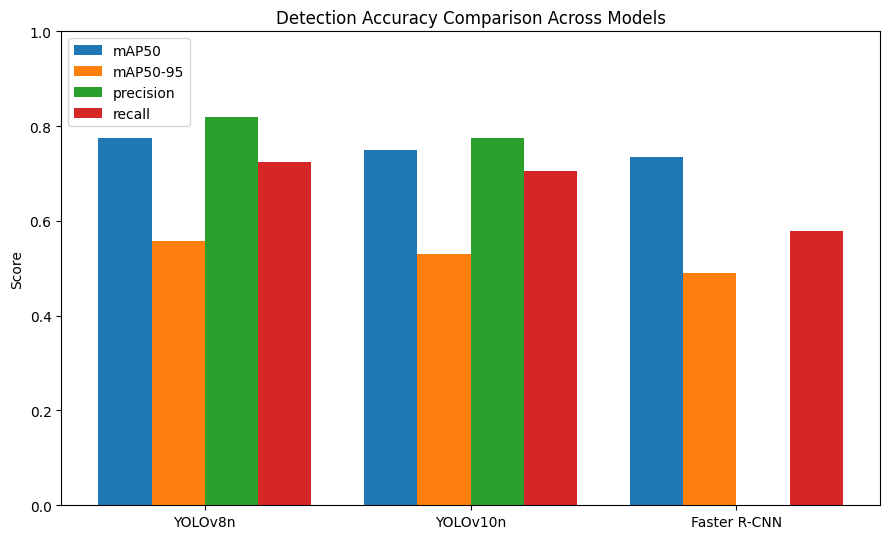

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/dissertation_project/results/model_comparison_full.csv")

metrics = ["mAP50", "mAP50-95", "precision", "recall"]
x = np.arange(len(df))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, df[metric], width, label=metric)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(df["model"])
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Detection Accuracy Comparison Across Models")
ax.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dissertation_project/results/accuracy_comparison.png", dpi=300)
plt.show()

# Bar chart — inference speed (FPS)
## separate chart since the scale is wildly different from the accuracy metrics (27 to 368):

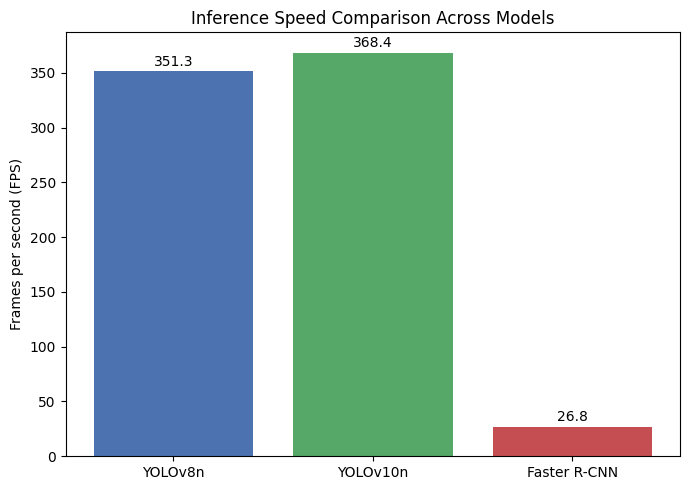

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(df["model"], df["fps"], color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Frames per second (FPS)")
ax.set_title("Inference Speed Comparison Across Models")
for bar, val in zip(bars, df["fps"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, f"{val:.1f}", ha="center")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dissertation_project/results/fps_comparison.png", dpi=300)
plt.show()

#